# Student Performance Dataset Project

## Project Overview
This project uses the **Student Performance Dataset** from the UCI Machine Learning Repository. The dataset contains information collected from Portuguese secondary school students, including demographics, study habits, family background, social behaviors, and academic performance.

The main goal of this project is to analyze factors that may affect student academic success and build machine learning models to predict student performance.

## Dataset Source
UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/320/student+performance

## Citations
- AI tools for Python and Latex Syntax/debuggin, and writing assistance
- Lecture Notes

## Possible Research Questions
- Does study time improve student grades?
- Do absences negatively affect academic performance?
- How does family support relate to grades?
- Can we predict final grades using student lifestyle and academic information?

## Project Goals
1. Download and load the dataset
2. Explore and clean the data
3. Visualize important relationships
4. Build predictive models
5. Evaluate model performance


In [525]:
# Install the package if needed:
# !pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Fetch the Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Extract features and targets
X = student_performance.data.features
y = student_performance.data.targets

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

# Save a local CSV copy
df.to_csv("student_performance.csv", index=False)

print("Dataset downloaded successfully!")
print("Dataset shape:", df.shape)


Dataset downloaded successfully!
Dataset shape: (649, 33)


### Dataset

In [526]:
# Preview the dataset

display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [527]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

The dataset has no missing values in any of the columns as follows:

In [528]:
print("\nMissing Values:")
print(df.isnull().sum().head())


Missing Values:
school     0
sex        0
age        0
address    0
famsize    0
dtype: int64


#### Variable Types

In [529]:
variable_types = {
    'school': 'categorical',
    'sex': 'categorical',
    'age': 'discrete quantitative',
    'address': 'categorical',
    'famsize': 'categorical',
    'Pstatus': 'categorical',
    'Medu': 'ordinal',
    'Fedu': 'ordinal',
    'Mjob': 'categorical',
    'Fjob': 'categorical',
    'reason': 'categorical',
    'guardian': 'categorical',
    'traveltime': 'ordinal',
    'studytime': 'ordinal',
    'failures': 'discrete quantitative',
    'schoolsup': 'categorical',
    'famsup': 'categorical',
    'paid': 'categorical',
    'activities': 'categorical',
    'nursery': 'categorical',
    'higher': 'categorical',
    'internet': 'categorical',
    'romantic': 'categorical',
    'famrel': 'ordinal',
    'freetime': 'ordinal',
    'goout': 'ordinal',
    'Dalc': 'ordinal',
    'Walc': 'ordinal',
    'health': 'ordinal',
    'absences': 'discrete quantitative',
    'G1': 'discrete quantitative',
    'G2': 'discrete quantitative',
    'G3': 'target variable'
}

## Exploratory Data Analysis Visualizations

### Grade Distributions: G1, G2, and G3

In [530]:
# Targets
grades = student_performance.data.targets

# Features
features = student_performance.data.features

Text(0.5, 0, 'Grades')

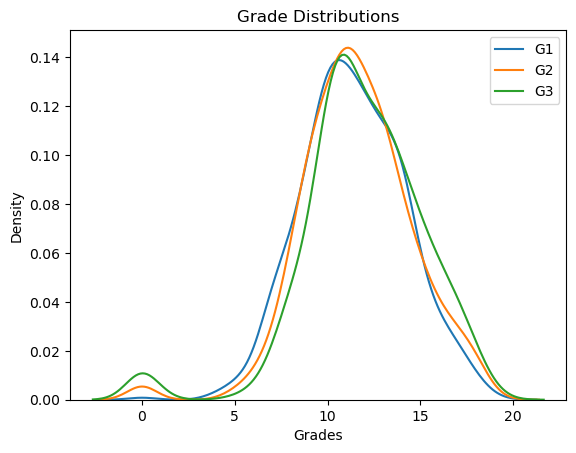

In [531]:
for col in grades.columns:
    sns.kdeplot(data=grades, x=col, label=col)


plt.legend()
plt.title("Grade Distributions")
plt.xlabel('Grades')

The grade distributions for G1, G2, and G3 show that most students score in the middle range from 10 to 14. The three grade distributions look fairly similar, which suggests that students’ performance is pretty consistent across the grading periods. However, G3 has some very low values, including 0, which may represent students who fail to complete courseworks and final exams.

### Reason for Choosing School vs Final Grade

/var/folders/r2/plrh1xlx4_b6wmq2hw3_92dw0000gn/T/ipykernel_23827/3225566461.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['traveltime_label'] = features['traveltime'].map(traveltime_map)


<Axes: xlabel='reason', ylabel='G3'>

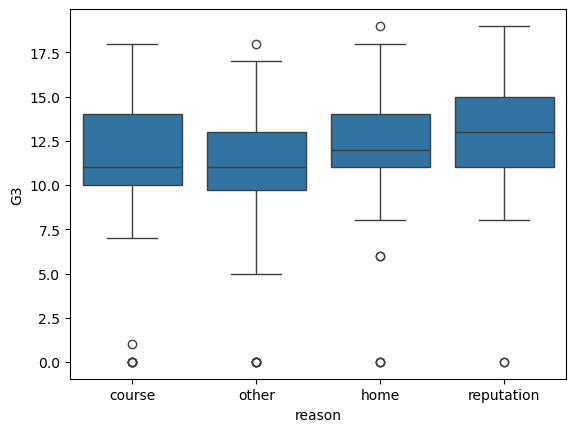

In [532]:
traveltime_map = {
    1: "<15 min",
    2: "15-30 min",
    3: "30-60 min",
    4: ">1 hour"
}

features['traveltime_label'] = features['traveltime'].map(traveltime_map)

combined = combined = pd.concat([features, grades], axis=1)
sns.boxplot(x='reason', y='G3', data=combined)

This boxplot compares final grades across the following reasons for choosing the school: course preference, reputation, home, or other reasons. Certain groups have higher median grades than others, but there is still huge variations within each group.

### Absences vs Final Grade

This scatter plot identifies whether trends, clusters, and possible outliers, when analyzing the relationship between student attendance and academic performance.

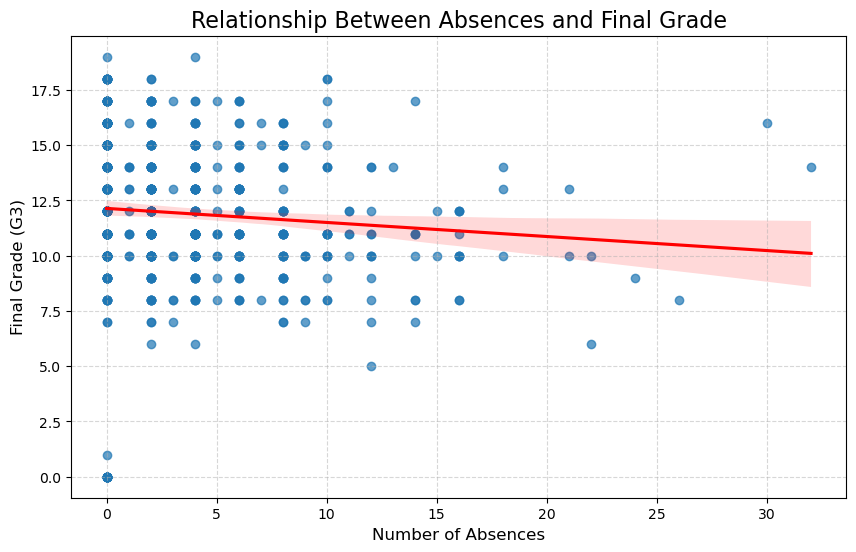

In [533]:
# Scatter plot: Absences vs Final Grade

plt.figure(figsize=(10,6))

sns.regplot(
    x='absences',
    y='G3',
    data=combined,
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}
)

plt.title('Relationship Between Absences and Final Grade', fontsize=16)
plt.xlabel('Number of Absences', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The scatter plot shows 
* Most students have relatively few absences, while a few students have extreme high numbers absences
* Weak negative correlation between absences and final grade: students with more absences may tend to have lower final grades. 
* Heteroskedasticity: Larger variations in final grade among students with lower numbers of absences, but this variation decreases as number of absences increase.

### Study Time vs Final Grade

This bar plot compares the average final grade (`G3`) for students across different weekly study-time groups to show whether spending more time studying is associated with better academic performance. Grouping students based on study time better compares academic performances based on various study habits.


/var/folders/r2/plrh1xlx4_b6wmq2hw3_92dw0000gn/T/ipykernel_23827/3235527698.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


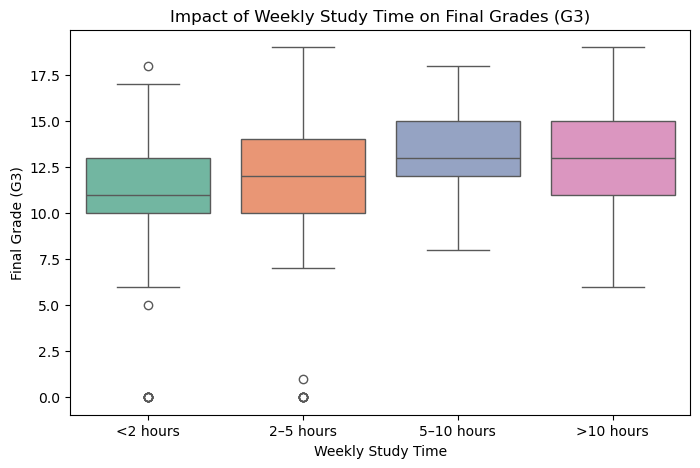

In [534]:
studytime_map = {
    1: "<2 hours",
    2: "2–5 hours",
    3: "5–10 hours",
    4: ">10 hours"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["studytime"].map(studytime_map),
    y=df["G3"],
    palette="Set2",
    order=["<2 hours", "2–5 hours", "5–10 hours", ">10 hours"]
)

plt.title("Impact of Weekly Study Time on Final Grades (G3)")
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()

Students with higher weekly study time tend to have higher median final grades. Students who dedicate at least 5 hours to studying are shown to have better performances than students who studied for less. 

### Average Final Grade by Study Time and Failures Explanation

This heatmap shows the average final grade (`G3`) for students based on two variables: study time and number of past failures. The rows represent different study time levels, and the columns represent the number of past class failures. Each cell shows the average final grade for that group.

This plot is useful because it shows how two factors may work together. In general, students with fewer past failures tend to have higher final grades. Students with more study time may also perform better, but past failures seem to have a strong relationship with lower grades. This suggests that academic history is an important factor when looking at final performance.

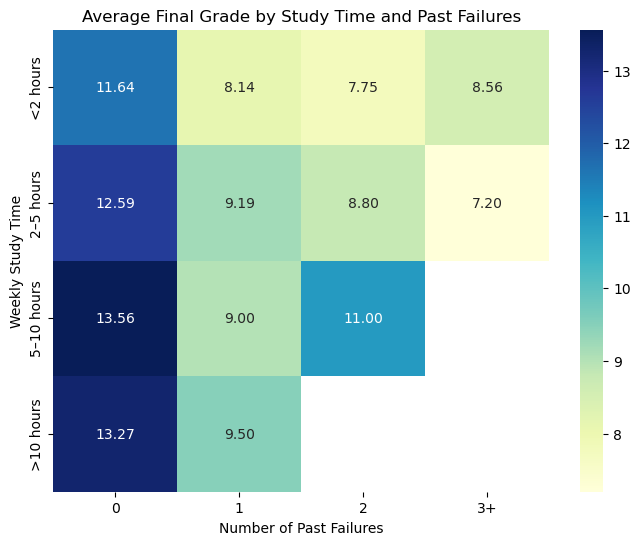

In [535]:
studytime_map = {
    1: "<2 hours",
    2: "2–5 hours",
    3: "5–10 hours",
    4: ">10 hours"
}

failures_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3+"
}

pivot_table = df.pivot_table(
    values="G3",
    index="studytime",
    columns="failures",
    aggfunc="mean"
)

# Relabel rows and columns
pivot_table.index = pivot_table.index.map(studytime_map)
pivot_table.columns = pivot_table.columns.map(failures_map)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Final Grade by Study Time and Past Failures")
plt.xlabel("Number of Past Failures")
plt.ylabel("Weekly Study Time")

plt.show()

This heatmap shows that students with fewer past failures usually have higher final grades, while students with more failures tend to have lower final grades. Study time also matters, but failures appear to have a stronger effect than study time. For example, students with no past failures usually perform better than students with multiple failures, even when study time changes. This suggests that failures is an important academic-history variable and should probably be included in the model.

### Alcohol Consumption Impact Explanation

The plot compares the relationship between Weekday (`Dalc`) and Weekend (`Walc`) Alcohol consumption and students' final grades. 

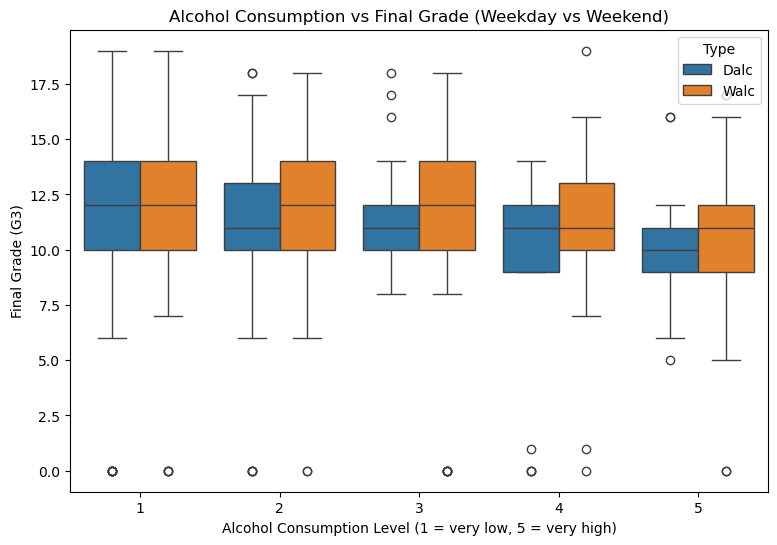

In [536]:
df_melt = df.melt(
    id_vars=["G3"],
    value_vars=["Dalc", "Walc"],
    var_name="Alcohol_Type",
    value_name="Consumption"
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_melt,
    x="Consumption",
    y="G3",
    hue="Alcohol_Type"
)

plt.title("Alcohol Consumption vs Final Grade (Weekday vs Weekend)")
plt.xlabel("Alcohol Consumption Level (1 = very low, 5 = very high)")
plt.ylabel("Final Grade (G3)")
plt.legend(title="Type")

plt.show()

This boxplot compares weekday (Dalc, blue) and weekend (Walc, orange) alcohol 
consumption against final grades (G3), broken out by consumption level 
(1 = very low, 5 = very high).

A few patterns stand out:

- **Weekend drinking (Walc) is consistently higher than weekday drinking (Dalc)** at every consumption level — the orange boxes sit higher and are wider, suggesting students who drink tend to drink more on weekends, with greater variability in outcomes.

- **Higher alcohol consumption is associated with slightly lower median grades** with medians declining from ~12 at level 1 to ~10–11 at level 5 for both types. The trend is modest, not dramatic.

- **Grade variability increases at higher consumption levels**, particularly for Walc, indicating that heavy weekend drinkers have more inconsistent academic outcomes.

- **Outliers** appear across all consumption levels, suggesting student dropout or absence rather than a direct alcohol effect.

In modeling, note that Dalc and Walc should be treated as separate predictors; combining them into a single total risks obscuring these distinct weekday vs. weekend patterns.

### Summary Statistics for Numerical Variables

This table summarizes the numerical variables in the dataset. It shows the count, mean, standard deviation, minimum, quartiles, and maximum for each numerical column.

This EDA is useful because it helps us understand the general range and distribution of the numerical features before building models. For example, we can see the average age of students, the average number of absences, the average grades, and whether some variables have extreme values or outliers.

In [537]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


The summary statistics show that the dataset contains 649 students. The average final grade G3 is about 11.91, and the median is 12, which means most students are around the passing range. The average number of absences is about 3.66, but the maximum is 32, showing that some students have much higher absences than most others. The variables G1, G2, and G3 all range from 0 to 19. This tells us that the dataset has some possible outliers, especially students with grade 0 and very high absences.

### Correlation Heatmap of all Predictors

This heatmap shows the correlation between all numerical variables in the dataset. Correlation values close to 1 mean that two variables have a strong positive relationship, while values close to -1 mean that two variables have a strong negative relationship.

This plot is useful because it helps us identify which features are most related to the final grade (G3). It also helps us detect relationships between predictors, such as whether G1 and G2 are strongly related to G3, or whether alcohol consumption and failures are negatively related to student performance.

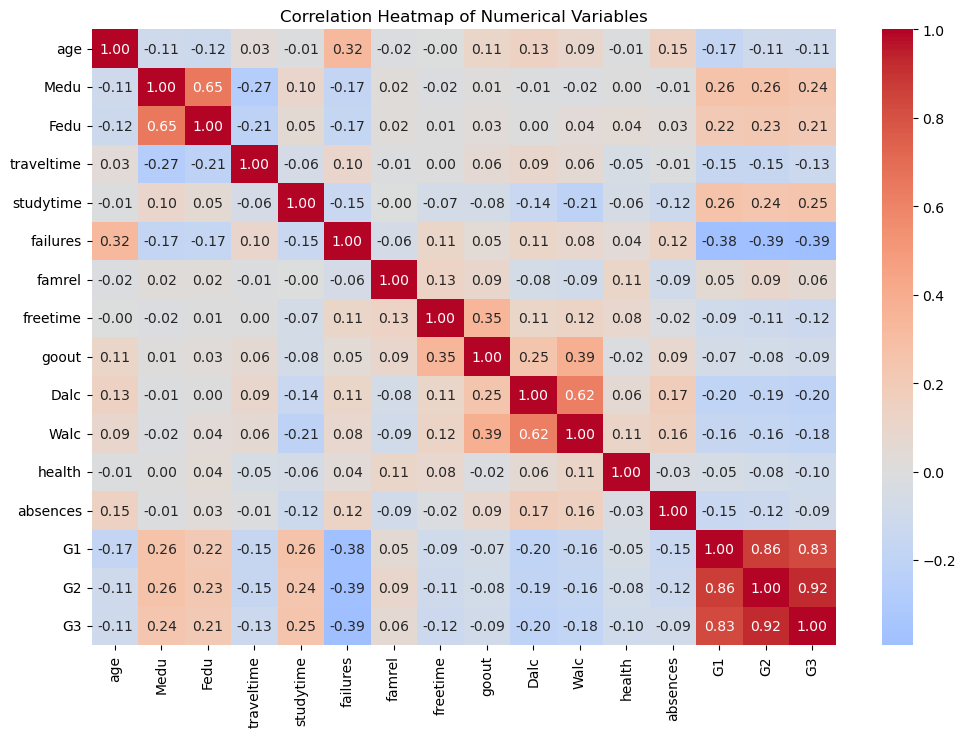

In [538]:
plt.figure(figsize=(12, 8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The correlation heatmap shows that G1 and G2 are strongly positively correlated with G3. This means earlier grades are very closely related to final grade. The heatmap also shows that failures, alcohol consumption, and travel time have negative relationships with final grade. This tells us that academic history is probably more predictive than lifestyle variables. For modeling, we should be careful because very strong correlations between G1, G2, and G3 may make the model depend heavily on previous grades.

### Correlation with Final Grade

This table ranks the numerical variables based on their correlation with the final grade (G3). Variables at the top have stronger positive relationships with final grade, while variables at the bottom have stronger negative relationships with final grade.

This EDA is useful because it directly shows which numerical features may be most important for predicting student academic performance. It can help guide feature selection when building machine learning models.

In [539]:
g3_corr = df[numeric_cols].corr()["G3"].sort_values(ascending=False)

print("Correlation with G3:")
display(g3_corr)

Correlation with G3:


G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

The correlation table confirms that G2 has the strongest relationship with G3, with a correlation of about 0.92. G1 is also very strongly related to G3, with a correlation of about 0.83. The strongest negative relationship is failures, with a correlation around -0.39. Study time, mother’s education, and father’s education have smaller positive correlations with final grade. This suggests that previous grades and past failures are the most important numerical predictors.

### Average Grade Progression from G1 to G3

This line plot shows the average student grade across three grading periods: G1, G2, and G3. Each point represents the average grade for that period.

This visualization is useful because it helps us understand whether students’ grades generally increase, decrease, or stay stable over time. Since G1 and G2 are earlier grades and G3 is the final grade, this plot also helps us understand how previous performance may relate to final performance.

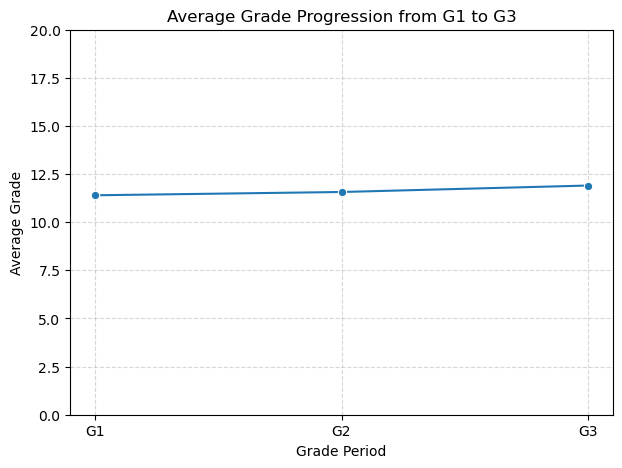

In [540]:
grade_means = df[["G1", "G2", "G3"]].mean()

plt.figure(figsize=(7, 5))

sns.lineplot(
    x=grade_means.index,
    y=grade_means.values,
    marker="o"
)

plt.title("Average Grade Progression from G1 to G3")
plt.xlabel("Grade Period")
plt.ylabel("Average Grade")
plt.ylim(0, 20)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The plot shows that average grades increase slightly from G1 to G2 to G3. This means that, on average, students’ grades are fairly stable and may improve a little over time. The change is not very large, so student performance does not dramatically shift between grading periods. This supports the idea that earlier grades can be strong predictors of final grade.

### Distribution of Final Grades with Pass/Fail Cutoff

The density histogram shows the distribution of students’ final grades (G3) and proportions of students who are passing with the red dashed line indicating the pass/fail cutoff of G3 = 10, where G3 >= 10 is considered passing. This is essential in future analysis, such as binary classification models that predict whether a student passes or fails

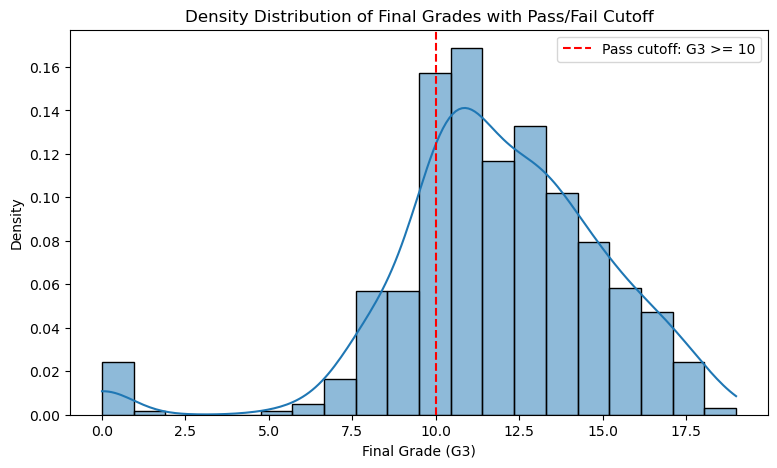

In [542]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    stat="density",   # key change
    kde=True
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    label="Pass cutoff: G3 >= 10"
)

plt.title("Density Distribution of Final Grades with Pass/Fail Cutoff")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Density")
plt.legend()

plt.show()

Based on the histogram, most of students are passing with scores concentrated around the range of 10 to 14. There are a number of students with final grades of 0, reflecting failure to complete or pass final assessment requirements.

### Average Final Grade by Parent Education Level

This heatmap shows the average final grade (G3) based on the education levels of the student’s mother (Medu) and father (Fedu). Each cell represents the average final grade for students with that combination of parent education levels.

This plot is useful because it helps us explore whether family educational background is related to student academic performance. If higher parent education levels are associated with higher average final grades, this may suggest that family background is an important factor in student success.

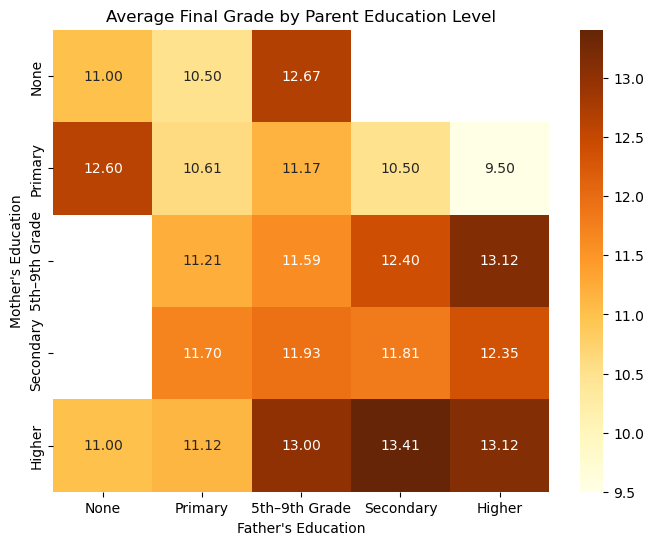

In [543]:
education_map = {
    0: "None",
    1: "Primary",
    2: "5th–9th Grade",
    3: "Secondary",
    4: "Higher"
}

parent_edu = df.groupby(["Medu", "Fedu"])["G3"].mean().reset_index()

pivot_parent = parent_edu.pivot(
    index="Medu",
    columns="Fedu",
    values="G3"
)

# Replace numeric codes with labels
pivot_parent.index = pivot_parent.index.map(education_map)
pivot_parent.columns = pivot_parent.columns.map(education_map)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot_parent,
    annot=True,
    fmt=".2f",
    cmap="YlOrBr"
)

plt.title("Average Final Grade by Parent Education Level")
plt.xlabel("Father's Education")
plt.ylabel("Mother's Education")

plt.show()

The parent education heatmap suggests that students whose parents have higher education levels often have higher average final grades. This pattern is especially visible when mother’s or father’s education is high. However, the relationship is not perfectly consistent across every combination, so parent education is likely helpful but not a complete explanation of student performance. For modeling, Medu and Fedu may be useful features, but they should be interpreted carefully because they may also reflect socioeconomic background.

### Second Period Grade vs Final Grade

This scatter plot shows the relationship between students’ second period grade (G2) and their final grade (G3). Each point represents one student, and the regression line shows the overall trend.

This plot is useful because it helps us see whether earlier academic performance is strongly related to final academic performance. If students with higher G2 scores also tend to have higher G3 scores, then G2 may be one of the strongest predictors of final grade.

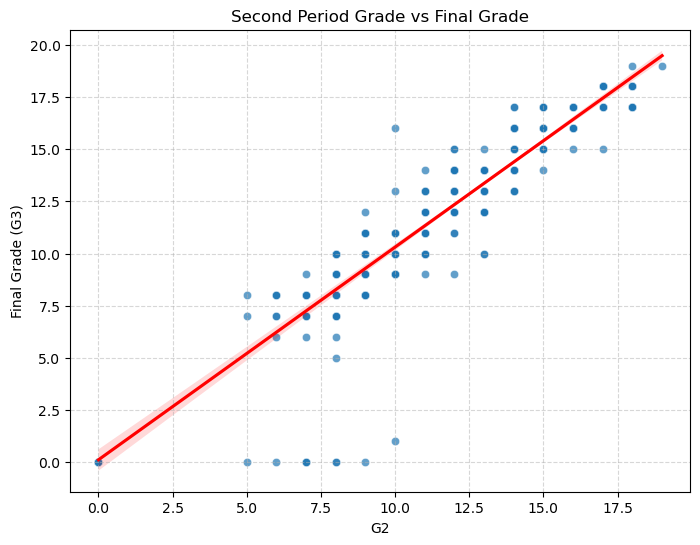

In [183]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="G2",
    y="G3",
    alpha=0.7
)

sns.regplot(
    data=df,
    x="G2",
    y="G3",
    scatter=False,
    color="red"
)

plt.title("Second Period Grade vs Final Grade")
plt.xlabel("G2")
plt.ylabel("Final Grade (G3)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The scatter plot between G2 and G3 shows a very strong positive relationship. Students with higher second-period grades usually have higher final grades. The points follow the regression line closely, which means G2 is probably one of the strongest predictors in the dataset. However, this also creates a modeling concern: if the goal is to predict final grade early, using G2 may cause data leakage because it is already very close to the final outcome.

### Final Grade Comparison by School

This boxplot compares the distribution of final grades (G3) between the two schools in the dataset: GP and MS.

This plot is useful because it helps us examine whether students from different schools have different academic performance patterns. If one school has a higher median grade or a different grade spread, school identity may be related to student performance.

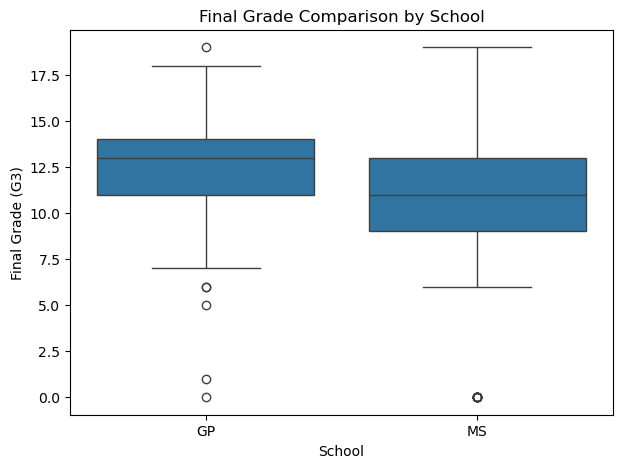

In [184]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="school",
    y="G3"
)

plt.title("Final Grade Comparison by School")
plt.xlabel("School")
plt.ylabel("Final Grade (G3)")

plt.show()

The school comparison boxplot shows that students from the two schools have somewhat different final grade distributions, but the distributions still overlap. One school may have a slightly higher median final grade, but school identity alone does not fully explain performance. This feature may be useful in the model, but we should avoid overinterpreting it because differences between schools may also reflect other factors such as student background, resources, or academic environment.

## Analyses

In [456]:
import numpy as np
import pandas as pd

# Data Processing for Model
from sklearn.model_selection import train_test_split

# Models Used
from sklearn.dummy import DummyRegressor
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression

# Ridge Regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import ElasticNet

from sklearn.linear_model import Lasso

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Regression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # Classification

In [457]:
def process_for_models(df_used, predictors, response):
    X = df_used[list(predictors)].drop(columns=[response])
    
    y = df_used[response]

    # Convert categorical variables into dummy variables
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    return X_train, X_test, y_train, y_test

def evaluation(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return rmse, mae, r2

# All predictors of the dataset except G1 and G2
all_vars = set(df.columns) - {'G1', 'G2'}

In [458]:
# store results in a dataframe
all_results = pd.DataFrame(columns=['RMSE', 'MAE', 'R²'])

### Residual Analysis

#### Why Analyze Residuals?

Residuals are the differences between actual grades and predicted grades. Examining residuals helps determine whether the model is making systematic errors.

A well-performing regression model should produce residuals that are randomly distributed around zero. Patterns in the residuals may indicate that the model is missing important relationships or that certain assumptions are being violated.

Residual analysis is commonly used to evaluate:

* Model bias
* Prediction consistency
* Underprediction or overprediction trends
* Potential nonlinear relationships

This analysis provides additional insight into the strengths and weaknesses of the regression model.


In [ ]:
X_rf = df.drop(columns=["G1", "G2", "G3"])
y_rf = df["G3"]

X_rf = pd.get_dummies(X_rf, drop_first=True)

from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf_reg.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_reg.predict(X_test_rf)

import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test_rf - y_pred_rf

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals
)

plt.axhline(0, color="red")
plt.title("Residual Plot (Random Forest)")
plt.xlabel("Predicted G3")
plt.ylabel("Residuals")

plt.show()


### Baseline regression: predict G3, excluding G1 and G2

In [459]:
def baseline_regression(df, predictors):
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = process_for_models(df, predictors, 'G3')

    # Baseline model: always predict the mean G3 from the training set
    baseline_reg = DummyRegressor(strategy="mean")
    baseline_reg.fit(X_train_reg, y_train_reg)

    # Predictions
    y_pred_reg = baseline_reg.predict(X_test_reg)

    # Evaluation

    return evaluation(y_test_reg, y_pred_reg)

baseline_rmse, baseline_mae, baseline_r2 = baseline_regression(df, all_vars)

print("Baseline Regression Results")
print("---------------------------")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"MAE:  {baseline_mae:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Regression Results
---------------------------
RMSE: 3.1726
MAE:  2.3946
R²:   -0.0322


In [460]:
all_results.loc['Baseline Regression', :] = np.array([baseline_rmse, baseline_mae, baseline_r2])


### Residual Analysis Discussion

The residual plot shows the prediction errors made by the model. Ideally, residuals should be randomly scattered around the zero line without any clear pattern.

If residuals appear evenly distributed, the model is capturing the underlying relationships reasonably well. However, visible patterns, clusters, or increasing spread may suggest that important variables or nonlinear relationships are not fully accounted for.

Residual analysis is useful because it evaluates not only how accurate predictions are, but also whether the model's errors occur systematically.


### Baseline classification: predict pass/fail, excluding G1 and G2

### Feature Importance Analysis

##### Why Analyze Feature Importance?

While model evaluation metrics such as RMSE, MAE, and R² tell us how well the model performs, they do not explain which variables are driving the predictions. Feature importance analysis helps identify the variables that contribute most to predicting student performance.

For this analysis, we use the Random Forest model because it naturally estimates feature importance based on how much each feature reduces prediction error across the decision trees. Understanding feature importance can provide insights into which student characteristics, academic history, and lifestyle factors are most associated with final grades.

This analysis helps answer the question:

**Which factors appear to have the greatest influence on student academic performance?**


In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_train_rf.columns,
    "Importance": rf_reg.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")
plt.show()

In [461]:
# Baseline Classification: Predict pass/fail
# Pass = 1 if G3 >= 10, Fail = 0 otherwise

df_class = df.copy()
df_class["pass"] = (df_class["G3"] >= 10).astype(int)

# Train-test split
all_vars.add("pass")
X_train_class, X_test_class, y_train_class, y_test_class = process_for_models(df_class, all_vars, "pass")

# Baseline model: always predict the most common class in the training set
baseline_class = DummyClassifier(strategy="most_frequent")
baseline_class.fit(X_train_class, y_train_class)

# Predictions
y_pred_class = baseline_class.predict(X_test_class)

# Evaluation
baseline_accuracy = accuracy_score(y_test_class, y_pred_class)
baseline_precision = precision_score(y_test_class, y_pred_class, zero_division=0, average="weighted")
baseline_recall = recall_score(y_test_class, y_pred_class, zero_division=0,  average="weighted")
baseline_f1 = f1_score(y_test_class, y_pred_class, zero_division=0,  average="weighted",)
baseline_cm = confusion_matrix(y_test_class, y_pred_class)

print("Baseline Classification Results")
print("-------------------------------")
print(f"Most frequent class predicted: {baseline_class.classes_[baseline_class.class_prior_.argmax()]}")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")
print()
baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=["Actual Fail", "Actual Pass"],
    columns=["Predicted Fail", "Predicted Pass"]
)

baseline_cm_df

Baseline Classification Results
-------------------------------
Most frequent class predicted: 1
Accuracy:  0.8846
Precision: 0.7825
Recall:    0.8846
F1 Score:  0.8305



,Predicted Fail,Predicted Pass
Actual Fail,0,15
Actual Pass,0,115


### Multiple linear regression without G1 and G2

In [462]:
all_vars.remove('pass')

In [463]:
# Multiple Linear Regression without G1 and G2

def multiple_linear_regression(df, predictors):
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = process_for_models(
        df, predictors, 'G3'
    )

    lin_reg = LinearRegression()
    lin_reg.fit(X_train_reg, y_train_reg)

    y_pred_lin = lin_reg.predict(X_test_reg)

    rmse, mae, r2 = evaluation(y_test_reg, y_pred_lin)

    return lin_reg, X_train_reg, rmse, mae, r2

lin_reg, X_reg, lin_rmse, lin_mae, lin_r2 = multiple_linear_regression(df, all_vars)

print("Linear Regression Results Without G1/G2")
print("---------------------------------------")
print(f"RMSE: {lin_rmse:.4f}")
print(f"MAE:  {lin_mae:.4f}")
print(f"R²:   {lin_r2:.4f}")

all_results.loc['Multiple Linear Regression', :] = np.array([lin_rmse, lin_mae, lin_r2])

Linear Regression Results Without G1/G2
---------------------------------------
RMSE: 2.8618
MAE:  2.1564
R²:   0.1602


Compare to the baseline regression

In [464]:
all_results

,RMSE,MAE,R²
Baseline Regression,3.17259,2.394605,-0.03216
Multiple Linear Regression,2.86178,2.156382,0.16017


In [465]:
coef_df = pd.DataFrame({
    "Feature": X_reg.columns,
    "Coefficient": lin_reg.coef_
})

coef_df["Abs Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Abs Coefficient", ascending=False).head(15)

,Feature,Coefficient,Abs Coefficient
29,higher_yes,1.686938,1.686938
16,schoolsup_yes,-1.603393,1.603393
2,failures,-1.498661,1.498661
25,school_MS,-1.393659,1.393659
23,Fjob_services,-1.099327,1.099327
17,Mjob_health,1.044890,1.044890
21,Fjob_health,-1.041107,1.041107
32,reason_other,-0.714842,0.714842
24,Fjob_teacher,-0.584711,0.584711
20,Mjob_teacher,0.550178,0.550178


### Ridge Regression Model

The ridge regression is a regularized regression model that adds an L2 penalty to the standard loss-function as follows: $$\text{Minimize: } \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^p \beta_j^2$$

The L2 penalty shrinks the coefficients of less informative predictors towards 0, but it rarely sets them exactly equal to zero. It reduces the magnitude of the coefficients more smoothly as a continuous shrinkage term. However unlike the L1 penalty used in the Lasso regression, it doesn't promote sparsity.

In [467]:
def ridge_regression(df, predictors, alpha_vals=None, best_alpha=1.0):
    if alpha_vals is None:
        alpha_vals = [0.001, 0.01, 0.1, 1, 10, 100]

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = process_for_models(
        df,
        predictors,
        "G3"
    )

    ridge_results = []

    for a in alpha_vals:
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=a)
        )

        model.fit(X_train_reg, y_train_reg)

        y_pred = model.predict(X_test_reg)

        rmse, mae, r2 = evaluation(y_test_reg, y_pred)

        ridge_results.append([a, rmse, mae, r2])

    ridge_df = pd.DataFrame(
        ridge_results,
        columns=["alpha", "RMSE", "MAE", "R²"]
    )

    print("Ridge Regression: Alpha Tuning Results")
    print(ridge_df.to_string(index=False))

    best_ridge = make_pipeline(
        StandardScaler(),
        Ridge(alpha=best_alpha)
    )

    best_ridge.fit(X_train_reg, y_train_reg)

    y_pred_ridge = best_ridge.predict(X_test_reg)

    ridge_rmse, ridge_mae, ridge_r2 = evaluation(
        y_test_reg,
        y_pred_ridge
    )

    return (
        best_ridge,
        ridge_df,
        ridge_rmse,
        ridge_mae,
        ridge_r2
    )


# Run Ridge Regression
best_ridge, ridge_df, ridge_rmse, ridge_mae, ridge_r2 = ridge_regression(
    df,
    set(df.columns) - {"G1", "G2"}
)

# Store results
all_results.loc["Ridge Regression"] = [
    ridge_rmse,
    ridge_mae,
    ridge_r2
]

# Print final model performance
print("\nRidge Regression Results Without G1/G2")
print("--------------------------------------")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE:  {ridge_mae:.4f}")
print(f"R²:   {ridge_r2:.4f}")

Ridge Regression: Alpha Tuning Results
  alpha     RMSE      MAE       R²
  0.001 2.861778 2.156381 0.160171
  0.010 2.861765 2.156368 0.160179
  0.100 2.861628 2.156240 0.160259
  1.000 2.860284 2.154973 0.161048
 10.000 2.848474 2.143553 0.167961
100.000 2.795970 2.080290 0.198352

Ridge Regression Results Without G1/G2
--------------------------------------
RMSE: 2.8603
MAE:  2.1550
R²:   0.1610


Evaluating different penalty terms

In [468]:
alpha_vals = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for a in alpha_vals:
    rmse, mae, r2 = ridge_regression_model(df, all_vars, "G3", a)
    
    results.append([a, rmse, mae, r2])

var_penalties = pd.DataFrame(results, columns=["alpha", "RMSE", "MAE", "R2"])

alpha_vals = var_penalties["alpha"].values
rmse_vals = var_penalties["RMSE"].values
mae_vals = var_penalties["MAE"].values
r2_vals = var_penalties["R2"].values

display(var_penalties)

,alpha,RMSE,MAE,R2
0,0.001,2.861778,2.156381,0.160171
1,0.010,2.861765,2.156368,0.160179
2,0.100,2.861628,2.156240,0.160259
3,1.000,2.860284,2.154973,0.161048
4,10.000,2.848474,2.143553,0.167961
5,100.000,2.795970,2.080290,0.198352


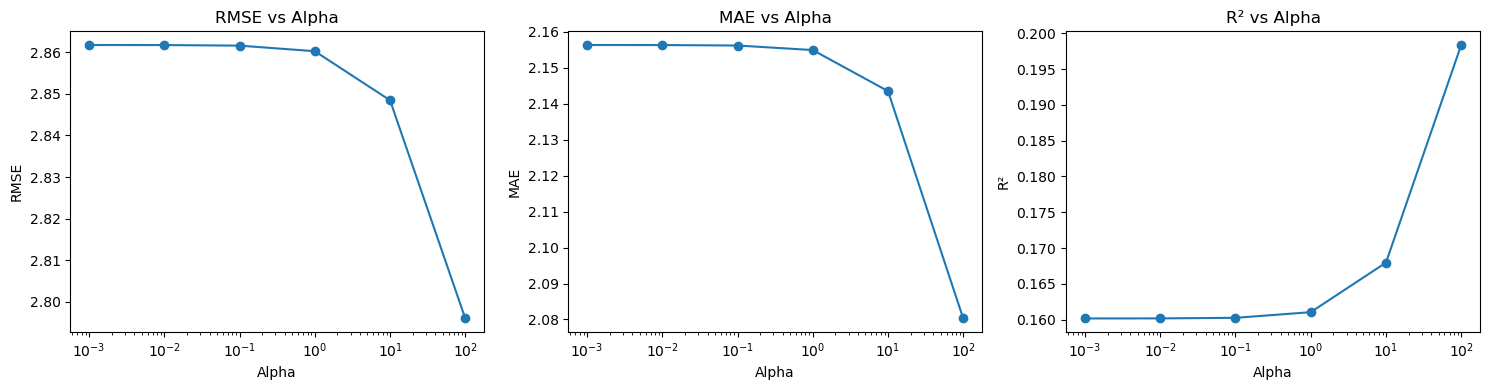

In [469]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# RMSE
ax[0].plot(alpha_vals, rmse_vals, marker='o')
ax[0].set_xscale('log')
ax[0].set_title('RMSE vs Alpha')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('RMSE')

# MAE
ax[1].plot(alpha_vals, mae_vals, marker='o')
ax[1].set_xscale('log')
ax[1].set_title('MAE vs Alpha')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('MAE')

# R2
ax[2].plot(alpha_vals, r2_vals, marker='o')
ax[2].set_xscale('log')
ax[2].set_title('R² vs Alpha')
ax[2].set_xlabel('Alpha')
ax[2].set_ylabel('R²')

plt.tight_layout()
plt.show()

### Random Forest Regression Model

In [470]:

def rf_regression(df, columns, response):

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = process_for_models(df, columns, response)

    rf_reg = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )

    rf_reg.fit(X_train_rf, y_train_rf)

    y_pred_rf = rf_reg.predict(X_test_rf)

    return evaluation(y_test_rf, y_pred_rf)

rf_rmse, rf_mae, rf_r2 = rf_regression(df, all_vars, "G3")

print("Random Forest Regression Results Without G1/G2")
print("----------------------------------------------")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R²:   {rf_r2:.4f}")

all_results.loc['Random Forest Regression', :] = [rf_rmse, rf_mae, rf_r2]

Random Forest Regression Results Without G1/G2
----------------------------------------------
RMSE: 2.8571
MAE:  2.0910
R²:   0.1629


In [471]:
comparison_reg = pd.DataFrame({
    "Model": [
        "Baseline Mean Model",
        "Linear Regression Without G1/G2",
        "Random Forest Regression Without G1/G2"
    ],
    "RMSE": [baseline_rmse, lin_rmse, rf_rmse],
    "MAE": [baseline_mae, lin_mae, rf_mae],
    "R²": [baseline_r2, lin_r2, rf_r2]
})

comparison_reg

,Model,RMSE,MAE,R²
0,Baseline Mean Model,3.172590,2.394605,-0.03216
1,Linear Regression Without G1/G2,2.861780,2.156382,0.16017
2,Random Forest Regression Without G1/G2,2.857056,2.091021,0.16294


The Random Forest Regression model performs slightly better than the regular Linear Regression model. Its RMSE and MAE are a little lower, and its R² is slightly higher, meaning it explains a little more variation in final grades. This makes sense because Random Forest can capture nonlinear patterns between variables, while Linear Regression assumes a straight-line relationship.

However, the improvement is not huge. This suggests that without using G1 and G2, student background, lifestyle, and support variables only explain part of final grade performance. Earlier grades are probably still the strongest predictors, but I excluded them here to avoid making the model too dependent on previous grade information.

### Lasso Regression Model

#### What is Lasso and why use it?

**Lasso** (Least Absolute Shrinkage and Selection Operator) is a regularized regression method that adds an **L1 penalty** to the standard least-squares loss:

$$\text{Minimize: } \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^p |\beta_j|$$

The L1 penalty shrinks coefficients of less informative predictors to exactly zero, effectively making it a useful tool for feature selection and determining the most important predictors in the dataset.

We use `StandardScaler` before fitting because Lasso is sensitive to the scale of features — without scaling, variables measured on larger scales would be penalized more than others.

In [472]:
def lasso_regression(df, predictors, alpha_vals=None, best_alpha=0.1):
    if alpha_vals is None:
        alpha_vals = [0.001, 0.01, 0.1, 1, 10, 100]

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = process_for_models(
        df, predictors, "G3"
    )

    lasso_results = []

    for a in alpha_vals:
        model = make_pipeline(
            StandardScaler(),
            Lasso(alpha=a, max_iter=10000)
        )

        model.fit(X_train_reg, y_train_reg)

        y_pred = model.predict(X_test_reg)

        rmse, mae, r2 = evaluation(y_test_reg, y_pred)

        lasso_results.append([a, rmse, mae, r2])

    lasso_df = pd.DataFrame(
        lasso_results,
        columns=["alpha", "RMSE", "MAE", "R²"]
    )

    print("Lasso Regression: Alpha Tuning Results")
    print(lasso_df.to_string(index=False))

    best_lasso = make_pipeline(
        StandardScaler(),
        Lasso(alpha=best_alpha, max_iter=10000)
    )

    best_lasso.fit(X_train_reg, y_train_reg)

    y_pred_lasso = best_lasso.predict(X_test_reg)

    lasso_rmse, lasso_mae, lasso_r2 = evaluation(
        y_test_reg,
        y_pred_lasso
    )

    return (
        best_lasso,
        X_train_reg,
        lasso_df,
        lasso_rmse,
        lasso_mae,
        lasso_r2
    )

In [473]:
lasso_model, X_reg, lasso_df, lasso_rmse, lasso_mae, lasso_r2 = (
    lasso_regression(df, all_vars)
)

print("\nLasso Regression Results Without G1/G2 (alpha=0.1)")
print("---------------------------------------------------")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"MAE:  {lasso_mae:.4f}")
print(f"R²:   {lasso_r2:.4f}")

all_results.loc["Lasso Regression", :] = [
    lasso_rmse,
    lasso_mae,
    lasso_r2
]

Lasso Regression: Alpha Tuning Results
  alpha     RMSE      MAE        R²
  0.001 2.859137 2.153830  0.161721
  0.010 2.838974 2.136447  0.173502
  0.100 2.806637 2.081960  0.192223
  1.000 3.072305 2.281234  0.032062
 10.000 3.172590 2.394605 -0.032160
100.000 3.172590 2.394605 -0.032160

Lasso Regression Results Without G1/G2 (alpha=0.1)
---------------------------------------------------
RMSE: 2.8066
MAE:  2.0820
R²:   0.1922


### Elastic Net Regression Model

#### What is Elastic Net and why use it?

**Elastic Net** combines both the L1 (Lasso) and L2 (Ridge) penalties into a single regularized regression:

$$\text{Minimize: } \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \left[ \gamma \sum_{j=1}^p |\beta_j| + (1 - \gamma) \sum_{j=1}^p \beta_j^2 \right]$$

where `alpha` ($\lambda$) controls the overall penalty strength and `l1_ratio` ($\gamma$) controls the **mix** between Lasso and Ridge:
- `l1_ratio = 1` → pure Lasso (L1 only)
- `l1_ratio = 0` → pure Ridge (L2 only)
- `l1_ratio = 0.5` → equal blend of both

**Why it is used here?**
- Lasso can be unstable when predictors are correlated with each other (multicollinearity). For example, mother's education (`Medu`) and father's education (`Fedu`) are likely correlated — Lasso may arbitrarily keep one and drop the other.
- Ridge handles correlated predictors better by shrinking them together, but it never drops any predictor entirely.
- Elastic Net gives us a middle ground: it can zero out truly irrelevant features (like Lasso) while still handling correlated groups of features gracefully (like Ridge).
- In a dataset like this with mixed-quality predictors and some correlation between family background variables, Elastic Net is a natural and robust choice.

We tuned `l1_ratio` to find the best balance between sparsity and stability for this dataset.

In [474]:
def elastic_net_regression(
    df,
    predictors,
    alpha=0.1,
    l1_ratios=None,
    best_l1_ratio=0.5
):
    if l1_ratios is None:
        l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = process_for_models(
        df,
        predictors,
        "G3"
    )

    en_results = []

    for l1 in l1_ratios:
        model = make_pipeline(
            StandardScaler(),
            ElasticNet(
                alpha=alpha,
                l1_ratio=l1,
                max_iter=10000
            )
        )

        model.fit(X_train_reg, y_train_reg)

        y_pred = model.predict(X_test_reg)

        rmse, mae, r2 = evaluation(y_test_reg, y_pred)

        en_results.append([l1, rmse, mae, r2])

    en_df = pd.DataFrame(
        en_results,
        columns=["l1_ratio", "RMSE", "MAE", "R²"]
    )

    print(
        f"Elastic Net Regression: l1_ratio Tuning Results (alpha={alpha})"
    )
    print(en_df.to_string(index=False))

    best_en = make_pipeline(
        StandardScaler(),
        ElasticNet(
            alpha=alpha,
            l1_ratio=best_l1_ratio,
            max_iter=10000
        )
    )

    best_en.fit(X_train_reg, y_train_reg)

    y_pred_en = best_en.predict(X_test_reg)

    en_rmse, en_mae, en_r2 = evaluation(
        y_test_reg,
        y_pred_en
    )

    return (
        best_en,
        X_train_reg,
        en_df,
        en_rmse,
        en_mae,
        en_r2
    )

In [475]:
elastic_net_model, X_reg, en_df, en_rmse, en_mae, en_r2 = (
    elastic_net_regression(df, all_vars)
)

print(
    "\nElastic Net Regression Results Without G1/G2 "
    "(alpha=0.1, l1_ratio=0.5)"
)
print("------------------------------------------------------------")
print(f"RMSE: {en_rmse:.4f}")
print(f"MAE:  {en_mae:.4f}")
print(f"R²:   {en_r2:.4f}")

all_results.loc["Elastic Net Regression", :] = [
    en_rmse,
    en_mae,
    en_r2
]

Elastic Net Regression: l1_ratio Tuning Results (alpha=0.1)
 l1_ratio     RMSE      MAE       R²
      0.1 2.804803 2.099330 0.193278
      0.3 2.799134 2.090274 0.196536
      0.5 2.799282 2.082814 0.196451
      0.7 2.804625 2.083177 0.193381
      0.9 2.805909 2.082837 0.192642

Elastic Net Regression Results Without G1/G2 (alpha=0.1, l1_ratio=0.5)
------------------------------------------------------------
RMSE: 2.7993
MAE:  2.0828
R²:   0.1965


### Summary

According to the table below, elastic net regression — a combination of ridge and lasso regularization — achieved the best results on the test set.

In [476]:
all_results

,RMSE,MAE,R²
Baseline Regression,3.17259,2.394605,-0.03216
Multiple Linear Regression,2.86178,2.156382,0.16017
Ridge Regression,2.860284,2.154973,0.161048
Random Forest Regression,2.857056,2.091021,0.16294
Lasso Regression,2.806637,2.08196,0.192223
Elastic Net Regression,2.799282,2.082814,0.196451


## Backward Selection

The backward selection process starts with the full model and iteratively removes predictors that least contributes to the model to minimize the selection criterions and will terminate until    $$ \min_{j \in \{i_1, i_2, \dots, i_k\}} C(\{x_{i_1}, x_{i_2}, \dots, x_{i_k}\} \setminus x_j) > C(\{x_{i_1}, x_{i_2}, \dots, x_{i_k}\}) $$

The two criterions that will be used are the **Akaike Information Criterion (AIC)** and the **Bayesian Information Criterion (BIC)**, which are measures of goodness of fit of a model, adjusted for number of predictors based on log-likelihood of model and number of predictors.


In [477]:
import statsmodels.formula.api as smf

# Backward Selection from Homework 4

def aic_criterion(formula, df):
    """
    Calculate the AIC for a given regression model formula and given dataframe.

    Parameters:
    formula (str): The regression model formula.
    df (pandas.DataFrame): The dataframe containing the data.

    Returns:
    float: The BIC value of the fitted model.
    """
    model = smf.ols(formula, df).fit()
    criterion_value = model.aic
    return criterion_value

def bic_criterion(formula, df):
    """
    Calculate the BIC for a given regression model formula and given dataframe.

    Parameters:
    formula (str): The regression model formula.
    df (pandas.DataFrame): The dataframe containing the data.

    Returns:
    float: The BIC value of the fitted model.
    """
    model = smf.ols(formula, df).fit()
    criterion_value = model.bic
    return criterion_value

def remove(df, already_selected_columns, criterion, response='y'):
    """
    Identify the worst column to remove based on the given criterion.
    REMEMBER: The smaller the criterion, the better the model.

    Parameters:
    df (pandas.DataFrame): The dataframe containing the data.
    already_selected_columns (set): The set of currently selected columns.
    criterion (function): The criterion function to evaluate the model.
    response (str): The response variable name.

    Returns:
    tuple: The worst column to remove and its criterion value.
    """

    # initialize the worst criterion and column to None
    worst_criterion = None
    worst_column = None

    # iterate over the already selected columns to find the worst column to remove
    for column in already_selected_columns:
        new_columns = [c for c in already_selected_columns if c != column]
        formula = f'{response} ~ {" + ".join(new_columns)}'
        current_criterion = criterion(formula, df)
        if worst_criterion is None or current_criterion < worst_criterion:
            worst_criterion = current_criterion
            worst_column = column
    return worst_column, worst_criterion

def backward(df, criterion, response='y'):
    """
    Perform backward selection to find the optimal model based on the given criterion.
    REMEMBER: The smallest criterion value is considered the best model fit.
    
    Parameters:
    df (pandas.DataFrame): The dataframe containing the data.
    criterion (function): The criterion function to evaluate the model.
    response (str): The response variable name.

    Returns:
    set: The set of selected columns in the optimal model.
    """

    # initialize the set of already selected columns to all columns except the response variable
    already_selected_columns = set(df.columns.drop(response))
    formula = f'{response} ~ {" + ".join(already_selected_columns)}'
    best_criterion = criterion(formula, df)
    print(best_criterion)
    while len(already_selected_columns) > 0:

        # identify the worst column to remove based on the given criterion
        potential_column, current_criterion = remove(df, already_selected_columns, criterion, response)

        # check if the model with the worst column removed has a better criterion value
        if current_criterion <= best_criterion:
            already_selected_columns = already_selected_columns - {potential_column}
            formula = f'{response} ~ {" + ".join(already_selected_columns)}'
            best_criterion = criterion(formula, df)
            print(f'Criterion: {best_criterion}')
        else:
            break
    final_selection = already_selected_columns
    return final_selection

In [506]:
backward_select_results = pd.DataFrame(columns=['RMSE', 'MAE', 'R^2'])

### Selection Criterion: AIC

Defined as follows: $$ AIC = -2 \ell(\beta) + 2p $$

where $p$ is the number of predictors and $n$ is the number of observations.

In [445]:
# Backward variable selection with the AIC criterion
without_G12 = df.drop(columns=['G1', 'G2'])
backward_vars_aic = backward(without_G12, aic_criterion, 'G3')
backward_vars_aic.add("G3")
backward_vars_aic

3152.938935027195
Criterion: 3149.1657108981926
Criterion: 3145.7975522022134
Criterion: 3143.811678142165
Criterion: 3141.9211712118777
Criterion: 3140.1756067646074
Criterion: 3138.5360872180872
Criterion: 3137.1533955847917
Criterion: 3135.929046375887
Criterion: 3134.625150743521
Criterion: 3133.519070170406
Criterion: 3132.564177480511
Criterion: 3131.813416044063
Criterion: 3131.1625128222768
Criterion: 3130.257667097878
Criterion: 3129.547371171964
Criterion: 3129.386514702834
Criterion: 3129.386514702834
Criterion: 3127.5885583724757


{'Fedu',
 'G3',
 'absences',
 'age',
 'failures',
 'health',
 'higher',
 'internet',
 'romantic',
 'school',
 'schoolsup',
 'sex',
 'studytime',
 'total_alcohol'}

In [507]:
lasso_model, X_reg, lasso_df, lasso_rmse, lasso_mae, lasso_r2 = (
    lasso_regression(
        df,
        backward_vars_aic,
        alpha_vals=[0.001, 0.01, 0.1, 1, 10, 100],
        best_alpha=0.01
    )
)

print("\nLasso Regression Results with AIC-Selected Variables (alpha=0.1)")
print("----------------------------------------------------------------")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"MAE:  {lasso_mae:.4f}")
print(f"R²:   {lasso_r2:.4f}")

backward_select_results.loc["Lasso Regression: AIC", :] = [
    lasso_rmse,
    lasso_mae,
    lasso_r2
]

Lasso Regression: Alpha Tuning Results
  alpha     RMSE      MAE        R²
  0.001 2.773448 2.103213  0.211214
  0.010 2.772385 2.099208  0.211819
  0.100 2.778735 2.070819  0.208204
  1.000 3.072305 2.281234  0.032062
 10.000 3.172590 2.394605 -0.032160
100.000 3.172590 2.394605 -0.032160

Lasso Regression Results with AIC-Selected Variables (alpha=0.1)
----------------------------------------------------------------
RMSE: 2.7724
MAE:  2.0992
R²:   0.2118


In [508]:
best_ridge, ridge_df, ridge_rmse, ridge_mae, ridge_r2 = ridge_regression(
    df,
    backward_vars_aic,
    best_alpha=100
)

print("Ridge Regression Results Using AIC-Selected Variables")
print("----------------------------------------------------")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE:  {ridge_mae:.4f}")
print(f"R²:   {ridge_r2:.4f}")

backward_select_results.loc["Ridge Regression: AIC"] = [
    ridge_rmse,
    ridge_mae,
    ridge_r2
]

Ridge Regression: Alpha Tuning Results
  alpha     RMSE      MAE       R²
  0.001 2.773588 2.103657 0.211135
  0.010 2.773584 2.103652 0.211137
  0.100 2.773543 2.103600 0.211160
  1.000 2.773139 2.103076 0.211390
 10.000 2.769330 2.097928 0.213555
100.000 2.748229 2.058188 0.225494
Ridge Regression Results Using AIC-Selected Variables
----------------------------------------------------
RMSE: 2.7482
MAE:  2.0582
R²:   0.2255


In [509]:
best_en, X_train_reg, en_df, en_rmse, en_mae, en_r2 = elastic_net_regression(df, backward_vars_aic)

print("Elastic Net Regression Results Using AIC-Selected Variables")
print("----------------------------------------------------")
print(f"RMSE: {en_rmse:.4f}")
print(f"MAE:  {en_mae:.4f}")
print(f"R²:   {en_r2:.4f}")

backward_select_results.loc["Elastic Net Regression: AIC"] = [
    en_rmse,
    en_mae,
    en_r2
]

Elastic Net Regression: l1_ratio Tuning Results (alpha=0.1)
 l1_ratio     RMSE      MAE       R²
      0.1 2.757713 2.075222 0.220139
      0.3 2.761268 2.073672 0.218127
      0.5 2.765841 2.072366 0.215535
      0.7 2.771552 2.071368 0.212293
      0.9 2.776647 2.070649 0.209394
Elastic Net Regression Results Using AIC-Selected Variables
----------------------------------------------------
RMSE: 2.7658
MAE:  2.0724
R²:   0.2155


### Selection Criterion: BIC

Defined as follows: $$BIC = -2 \ell(\beta) + p \log(n) $$

where $p$ is the number of predictors and $n$ is the number of observations.

In [483]:
backward_vars_bic = backward(without_G12, bic_criterion, 'G3')
backward_vars_bic.add("G3")
backward_vars_bic

3331.9562436953584
Criterion: 3310.28128869954
Criterion: 3291.0247419849557
Criterion: 3274.363376583541
Criterion: 3263.7099348076295
Criterion: 3257.2762177258737
Criterion: 3250.987309105904
Criterion: 3244.817871440119
Criterion: 3238.655745995365
Criterion: 3233.0846705110107
Criterion: 3227.503157221192
Criterion: 3222.0728318145925
Criterion: 3216.846637661441
Criterion: 3211.7203017229504
Criterion: 3206.3400232818476
Criterion: 3201.1542946392296
Criterion: 3196.5180054533953
Criterion: 3192.2426374519723
Criterion: 3188.5120172826823
Criterion: 3185.0210840308578
Criterion: 3181.515821114905
Criterion: 3178.6743500893035
Criterion: 3178.6743500893035
Criterion: 3172.58558758337


{'Fedu',
 'G3',
 'failures',
 'health',
 'higher',
 'school',
 'schoolsup',
 'studytime',
 'total_alcohol'}

In [510]:
best_lasso, X_train_lasso, lasso_df, lasso_rmse, lasso_mae, lasso_r2 = lasso_regression(
    df,
    backward_vars_bic,
    best_alpha=0.1
)

print("\nLasso Regression Results Using BIC-Selected Variables (α = 0.1)")
print("---------------------------------------------------------------")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"MAE:  {lasso_mae:.4f}")
print(f"R²:   {lasso_r2:.4f}")

backward_select_results.loc["Lasso Regression: BIC"] = [
    lasso_rmse,
    lasso_mae,
    lasso_r2
]

Lasso Regression: Alpha Tuning Results
  alpha     RMSE      MAE        R²
  0.001 2.819329 2.143963  0.184901
  0.010 2.816195 2.138701  0.186712
  0.100 2.795114 2.092567  0.198842
  1.000 3.072305 2.281234  0.032062
 10.000 3.172590 2.394605 -0.032160
100.000 3.172590 2.394605 -0.032160

Lasso Regression Results Using BIC-Selected Variables (α = 0.1)
---------------------------------------------------------------
RMSE: 2.7951
MAE:  2.0926
R²:   0.1988


In [511]:
best_ridge, ridge_df, ridge_rmse, ridge_mae, ridge_r2 = ridge_regression(
    df,
    backward_vars_bic,
    best_alpha=100
)

print("\nRidge Regression Results Using BIC-Selected Variables (α = 1.0)")
print("---------------------------------------------------------------")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE:  {ridge_mae:.4f}")
print(f"R²:   {ridge_r2:.4f}")

backward_select_results.loc["Ridge Regression: BIC"] = [
    ridge_rmse,
    ridge_mae,
    ridge_r2
]

Ridge Regression: Alpha Tuning Results
  alpha     RMSE      MAE       R²
  0.001 2.819688 2.144545 0.184693
  0.010 2.819683 2.144540 0.184696
  0.100 2.819639 2.144490 0.184721
  1.000 2.819199 2.143988 0.184976
 10.000 2.815006 2.139061 0.187399
100.000 2.788956 2.100093 0.202369

Ridge Regression Results Using BIC-Selected Variables (α = 1.0)
---------------------------------------------------------------
RMSE: 2.7890
MAE:  2.1001
R²:   0.2024


In [512]:
best_en, X_train_reg, en_df, en_rmse, en_mae, en_r2 = elastic_net_regression(df, backward_vars_bic)

print("Elastic Net Regression Results Using AIC-Selected Variables")
print("----------------------------------------------------")
print(f"RMSE: {en_rmse:.4f}")
print(f"MAE:  {en_mae:.4f}")
print(f"R²:   {en_r2:.4f}")

backward_select_results.loc["Elastic Net Regression: BIC"] = [
    en_rmse,
    en_mae,
    en_r2
]

Elastic Net Regression: l1_ratio Tuning Results (alpha=0.1)
 l1_ratio     RMSE      MAE       R²
      0.1 2.799017 2.116409 0.196603
      0.3 2.797685 2.111070 0.197368
      0.5 2.796592 2.105530 0.197995
      0.7 2.795768 2.100104 0.198467
      0.9 2.795248 2.094909 0.198765
Elastic Net Regression Results Using AIC-Selected Variables
----------------------------------------------------
RMSE: 2.7966
MAE:  2.1055
R²:   0.1980


In [513]:
backward_select_results

,RMSE,MAE,R^2
Lasso Regression: AIC,2.772385,2.099208,0.211819
Ridge Regression: AIC,2.748229,2.058188,0.225494
Elastic Net Regression: AIC,2.765841,2.072366,0.215535
Lasso Regression: BIC,2.795114,2.092567,0.198842
Ridge Regression: BIC,2.788956,2.100093,0.202369
Elastic Net Regression: BIC,2.796592,2.10553,0.197995
